# SHAP Explainability — LightGBM Model

This notebook applies SHAP to interpret the final LightGBM model used for flight delay prediction.

The goal is to understand which features contribute the most to the model predictions and how they influence the probability of delay.

In [1]:
# Imports

import pandas as pd
import numpy as np
import joblib
import shap

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams["figure.figsize"] = (10, 6)

/Users/Cliscia-Aula/.pyenv/versions/3.12.9/envs/flight-risk/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Data and Trained Model

df = pd.read_parquet("../.data/flights_features_updated.parquet")

model = joblib.load("../.data/model/lgbm_binary.pkl")

print(f"Dataset shape: {df.shape}")
print("Model loaded successfully.")

Dataset shape: (2964978, 57)
Model loaded successfully.


In [3]:
# Define Features, Target and Temporal Spli

TARGET = "is_delayed"
METADATA = ["dep_scheduled"]

X = df.drop(columns=[TARGET] + METADATA)
y = df[TARGET]

VAL_CUTOFF = "2025-07-01"

dates = df["dep_scheduled"]

train_mask = dates.dt.year.isin([2022, 2023, 2024])
val_mask = (~train_mask) & (dates < VAL_CUTOFF)
test_mask = (~train_mask) & (dates >= VAL_CUTOFF)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train:      {len(X_train):,} rows")
print(f"Validation: {len(X_val):,} rows")
print(f"Test:       {len(X_test):,} rows")

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Train:      2,193,914 rows
Validation: 379,819 rows
Test:       391,245 rows

Test target distribution:
is_delayed
0   83.920
1   16.080
Name: proportion, dtype: float64


In [4]:
# Load preprocessing artifacts

encoders = joblib.load("../.data/model/encoders.pkl")
airline_hour_stats = joblib.load("../.data/model/airline_hour_stats.pkl")
route_stats = joblib.load("../.data/model/route_stats.pkl")
airports_reference = pd.read_csv("../.data/model/airports_reference.csv")

print("Artifacts loaded successfully.")

Artifacts loaded successfully.


In [5]:
print(X_test.shape)

X_test.head()


(391245, 55)


,airline_icao,origin_icao,destination_icao,origin_elevation_ft,origin_region,destination_elevation_ft,destination_region,origin_wx_temperature_2m,origin_wx_precipitation,origin_wx_windspeed_10m,origin_wx_windgusts_10m,origin_wx_cloudcover,origin_wx_surface_pressure,destination_wx_temperature_2m,destination_wx_precipitation,destination_wx_windspeed_10m,destination_wx_windgusts_10m,destination_wx_cloudcover,destination_wx_surface_pressure,dep_day_of_year,dep_is_weekend,dep_hour_sin,dep_hour_cos,dep_dow_sin,dep_dow_cos,dep_month_sin,dep_month_cos,dep_time_block,dep_is_peak_hour,dep_is_holiday,route,region_pair,distance_km,flight_range,elevation_diff_ft,origin_airport_size,destination_airport_size,is_trunk_route,scheduled_duration_min,origin_hourly_flights,destination_hourly_arrivals,total_hourly_congestion,origin_wx_condition,destination_wx_condition,origin_wx_is_fog,origin_wx_is_rain,origin_wx_is_storm,destination_wx_is_fog,destination_wx_is_rain,destination_wx_is_storm,route_hist_delay_mean,route_hist_delay_std,route_hist_delay_rate,airline_hour_delay_rate,airline_hour_delay_mean
2523791,GLO,SBBE,SBSN,54.000,BR-PA,198.000,BR-PA,23.950,0.200,7.858,13.680,51.000,1014.017,24.450,2.100,14.767,28.080,99.000,1007.292,182,0,0.000,1.000,0.782,0.623,-0.500,-0.866,early_morning,0,0,SBBE_SBSN,BR-PA_BR-PA,711.524,medium,144.000,3.000,2.000,0,85.000,3,2,5,rain,rain,0,1,0,0,1,0,2.829,22.364,0.114,0.215,6.457
2573734,AZU,SBKP,SBRJ,2170.000,BR-SP,11.000,BR-RJ,18.350,0.000,3.976,17.280,0.000,947.195,22.681,0.000,8.778,25.920,13.000,1021.646,204,0,0.707,-0.707,0.975,-0.223,-0.500,-0.866,morning,1,0,SBKP_SBRJ,BR-SP_BR-RJ,406.778,short,-2159.000,3.000,3.000,0,65.000,12,5,17,clear,clear,0,0,0,0,0,0,4.217,20.655,0.136,0.110,2.788
2573735,AZU,SBKP,SBRJ,2170.000,BR-SP,11.000,BR-RJ,16.550,0.000,18.962,41.040,6.000,947.490,21.131,0.100,6.016,18.720,97.000,1024.143,205,0,0.707,-0.707,0.434,-0.901,-0.500,-0.866,morning,1,0,SBKP_SBRJ,BR-SP_BR-RJ,406.778,short,-2159.000,3.000,3.000,0,65.000,12,5,17,clear,rain,0,0,0,0,1,0,4.217,20.655,0.136,0.110,2.788
2573736,AZU,SBKP,SBRJ,2170.000,BR-SP,11.000,BR-RJ,16.800,0.000,9.907,25.920,96.000,945.700,22.081,0.000,4.847,18.360,99.000,1021.245,206,0,0.707,-0.707,-0.434,-0.901,-0.500,-0.866,morning,1,0,SBKP_SBRJ,BR-SP_BR-RJ,406.778,short,-2159.000,3.000,3.000,0,65.000,12,5,17,cloudy,cloudy,0,0,0,0,0,0,4.217,20.655,0.136,0.110,2.788
2573737,AZU,SBKP,SBRJ,2170.000,BR-SP,11.000,BR-RJ,15.550,0.000,8.906,27.360,4.000,945.389,21.331,0.000,2.886,19.080,57.000,1021.644,207,1,0.707,-0.707,-0.975,-0.223,-0.500,-0.866,morning,1,0,SBKP_SBRJ,BR-SP_BR-RJ,406.778,short,-2159.000,3.000,3.000,0,65.000,10,4,14,clear,cloudy,0,0,0,0,0,0,4.217,20.655,0.136,0.110,2.788


In [6]:
X_test.dtypes

airline_icao                            str
origin_icao                             str
destination_icao                        str
origin_elevation_ft                 float64
origin_region                           str
destination_elevation_ft            float64
destination_region                      str
origin_wx_temperature_2m            float32
origin_wx_precipitation             float32
origin_wx_windspeed_10m             float32
origin_wx_windgusts_10m             float32
origin_wx_cloudcover                float32
origin_wx_surface_pressure          float32
destination_wx_temperature_2m       float32
destination_wx_precipitation        float32
destination_wx_windspeed_10m        float32
destination_wx_windgusts_10m        float32
destination_wx_cloudcover           float32
destination_wx_surface_pressure     float32
dep_day_of_year                       int32
dep_is_weekend                        int64
dep_hour_sin                        float64
dep_hour_cos                    

In [7]:
# Encode Categorical Features for Model Input

CAT_COLS = [
    "airline_icao", "origin_icao", "destination_icao",
    "origin_region", "destination_region",
    "route", "region_pair", "flight_range",
    "dep_time_block",
    "origin_wx_condition", "destination_wx_condition",
]

X_test_encoded = X_test.copy()

for col in CAT_COLS:
    if col in X_test_encoded.columns:
        X_test_encoded[col] = X_test_encoded[col].astype(str)
        X_test_encoded[col] = encoders[col].transform(X_test_encoded[col])

print(X_test_encoded.shape)
print(X_test_encoded.dtypes.value_counts())

(391245, 55)
int64      24
float64    18
float32    12
int32       1
Name: count, dtype: int64


In [8]:
print(model.n_features_)

55


In [9]:
print(list(X_test_encoded.columns) == list(model.feature_name_))

True


In [10]:
# Test Model Predictions

y_pred = model.predict(X_test_encoded)
y_prob = model.predict_proba(X_test_encoded)[:, 1]

print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_prob.shape)

print("\nFirst predictions:")
print(y_pred[:10])

print("\nFirst probabilities:")
print(y_prob[:10])

Prediction shape: (391245,)
Probability shape: (391245,)

First predictions:
[0 0 0 0 0 0 0 0 0 0]

First probabilities:
[0.20910619 0.27622261 0.3353743  0.47835655 0.44840631 0.36608145
 0.2789844  0.30538748 0.37771886 0.47816556]


In [11]:
# Create SHAP Explainer

explainer = shap.TreeExplainer(model)

print("SHAP Explainer created successfully.")

SHAP Explainer created successfully.


In [12]:
# Create Sample for SHAP

X_sample = X_test_encoded.sample(
    n=3000,
    random_state=42
)

print(X_sample.shape)

(3000, 55)


In [13]:
# Calculate SHAP Values

shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


/Users/Cliscia-Aula/.pyenv/versions/3.12.9/envs/flight-risk/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


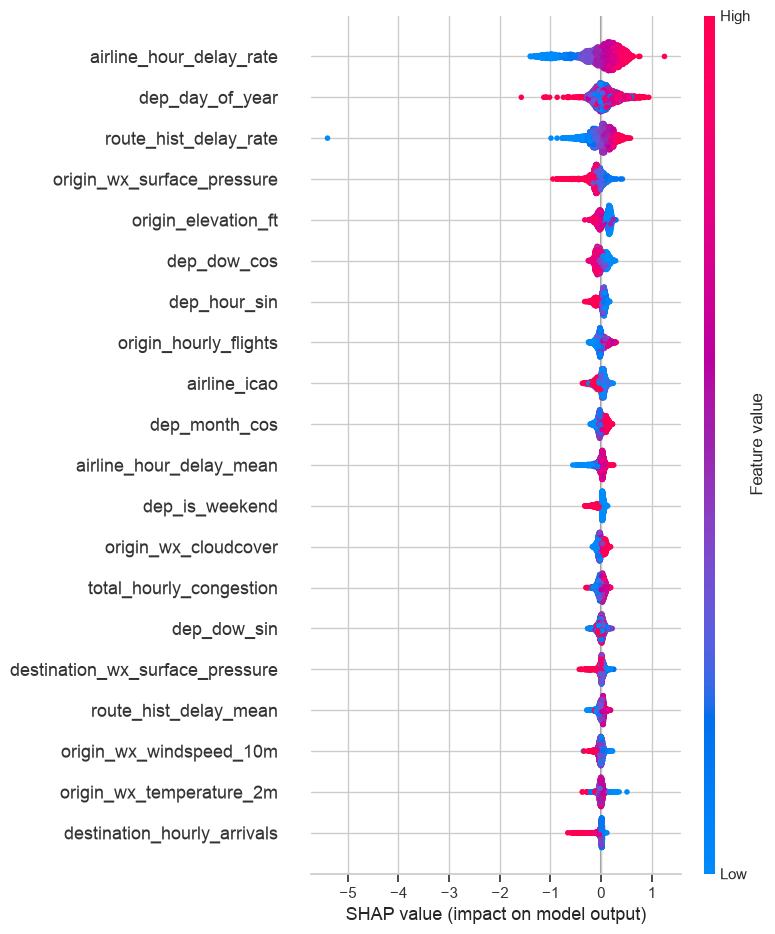

In [14]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_sample
)

### Interpretation

The Summary Plot ranks features by their average impact on the model output.

In this model, historical airline delay rate and historical route delay rate are the most influential predictors.

Higher values of these variables generally increase the probability of a delayed flight, indicating that the model successfully learned operational delay patterns rather than relying only on airport or airline identifiers.

In [15]:
# Interactive SHAP Feature Importance

import plotly.express as px

shap_importance = (
    pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .head(20)
)

fig = px.bar(
    shap_importance.sort_values("mean_abs_shap"),
    x="mean_abs_shap",
    y="feature",
    orientation="h",
    title="Top 20 Features by Mean Absolute SHAP Value",
    labels={
        "mean_abs_shap": "Mean |SHAP value|",
        "feature": ""
    },
    height=750
)

fig.update_layout(
    template="plotly_white",
    font=dict(size=15),
    title_x=0.5,
    margin=dict(l=230, r=40, t=70, b=50),
    yaxis=dict(
        tickfont=dict(size=14)
    ),
    xaxis=dict(
        title_font=dict(size=15),
        tickfont=dict(size=13)
    )
)

fig.show()

### Interpretation

This chart ranks the features according to their average absolute SHAP value, representing their overall contribution to the model's predictions.

The most influential variables are historical operational indicators, such as **airline_hour_delay_rate** and **route_hist_delay_rate**, suggesting that past delay patterns are the strongest predictors of future flight delays. Temporal features, including **dep_day_of_year**, also play an important role, while weather-related variables contribute with a smaller but still meaningful impact.

Overall, the model relies primarily on operational history and temporal information rather than airport or airline identifiers, indicating that it has learned meaningful patterns associated with flight delays.

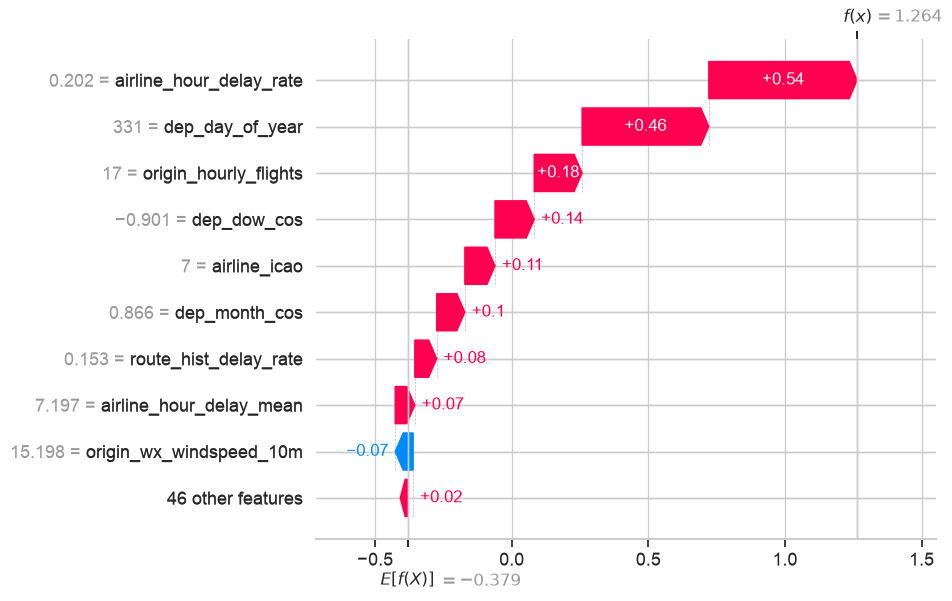

In [16]:
# Select Example Prediction

y_sample = y_test.loc[X_sample.index]
sample_index = np.where(y_sample == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_sample.iloc[sample_index],
        feature_names=X_sample.columns
    )
)

### Interpretation

This Waterfall Plot explains one delayed flight selected from the SHAP sample. The model starts from the baseline prediction and each feature pushes the prediction either toward or away from a delay.

For this flight, **airline_hour_delay_rate** and **dep_day_of_year** were the strongest positive contributors, meaning that historical airline delay behavior and seasonal timing increased the model output toward a delayed-flight prediction. **origin_hourly_flights** and **route_hist_delay_rate** also contributed positively, suggesting that airport activity and route delay history were relevant for this case.

Some variables, such as **origin_wx_windspeed_10m**, slightly reduced the prediction. Overall, this individual explanation shows that the model decision was mainly driven by historical operational patterns and temporal factors.

In [17]:
# Interactive SHAP Dependence Plot

feature = "airline_hour_delay_rate"

dependence_df = pd.DataFrame({
    feature: X_sample[feature],
    "shap_value": shap_values[:, list(X_sample.columns).index(feature)]
})

fig = px.scatter(
    dependence_df,
    x=feature,
    y="shap_value",
    title="SHAP Dependence Plot — Airline Historical Delay Rate",
    labels={
        feature: "Airline historical delay rate",
        "shap_value": "SHAP value"
    },
    opacity=0.65,
    height=600
)

fig.update_layout(
    template="plotly_white",
    font=dict(size=14),
    title_x=0.5,
    margin=dict(l=80, r=40, t=70, b=60)
)

fig.show()

### Interpretation

This dependence plot shows how **airline_hour_delay_rate** affects the model output across the sampled flights.

As the historical delay rate for an airline at a given hour increases, the SHAP value generally becomes more positive. This indicates that higher historical delay rates push the model toward predicting a delayed flight.

The relationship is clearly increasing, suggesting that the model learned a meaningful operational pattern: airlines with worse delay performance at specific hours tend to contribute more strongly to future delay predictions.

## Final Conclusions

SHAP analysis showed that the LightGBM model relies mainly on historical operational patterns to predict flight delays.

The most important features were related to airline delay history, route delay history, seasonality, and airport activity. This suggests that the model is not relying only on static identifiers, but is learning meaningful patterns associated with flight operations.

The individual explanation confirmed that a delayed-flight prediction was mainly driven by historical airline behavior, route performance, and temporal characteristics.

Overall, SHAP improved the interpretability of the model and helped validate that the model predictions are aligned with real operational factors.